### Author:<br>
Name: Zhihao Cui<br>
Institute: School of Mathematics and Statistics <br>
NO: 20233002662

单神经元 — 神经网络的最基本单元

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

print("=" * 50)
print("数据集信息")
print("=" * 50)
print(f"样本数量: {X.shape[0]}")
print(f"特征数量: {X.shape[1]}")
print(f"类别: {data.target_names}")  # ['malignant' 恶性, 'benign' 良性]
print(f"类别分布: 良性={sum(y==1)}, 恶性={sum(y==0)}")
print()

数据集信息
样本数量: 569
特征数量: 30
类别: ['malignant' 'benign']
类别分布: 良性=357, 恶性=212



In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# 神经网络对特征尺度敏感，需要将数据缩放到均值为 0，标准差为 1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
# LogisticRegression 本质上就是一个单神经元 + Sigmoid 激活函数
# 公式：y = sigmoid(w1*x1 + w2*x2 + ... + w30*x30 + b)
model = LogisticRegression()

In [6]:
print("正在训练单神经元模型...")
model.fit(X_train, y_train)

正在训练单神经元模型...


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [7]:
print("\n" + "=" * 50)
print("神经元的参数")
print("=" * 50)
print(f"偏置 (bias): {model.intercept_[0]:.4f}")
print(f"权重 (weights) 前 10 个: {model.coef_[0][:10]}")
print(f"权重总数: {len(model.coef_[0])} 个（每个特征对应一个权重）")


神经元的参数
偏置 (bias): 0.4456
权重 (weights) 前 10 个: [-0.43190368 -0.38732553 -0.39343248 -0.46521006 -0.07166728  0.54016395
 -0.8014581  -1.11980408  0.23611852  0.07592093]
权重总数: 30 个（每个特征对应一个权重）


In [8]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 50)
print("模型评估")
print("=" * 50)
print(f"准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")
print()
print("分类报告:")
print(classification_report(y_test, y_pred, target_names=data.target_names))


模型评估
准确率: 0.9737 (97.37%)

分类报告:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



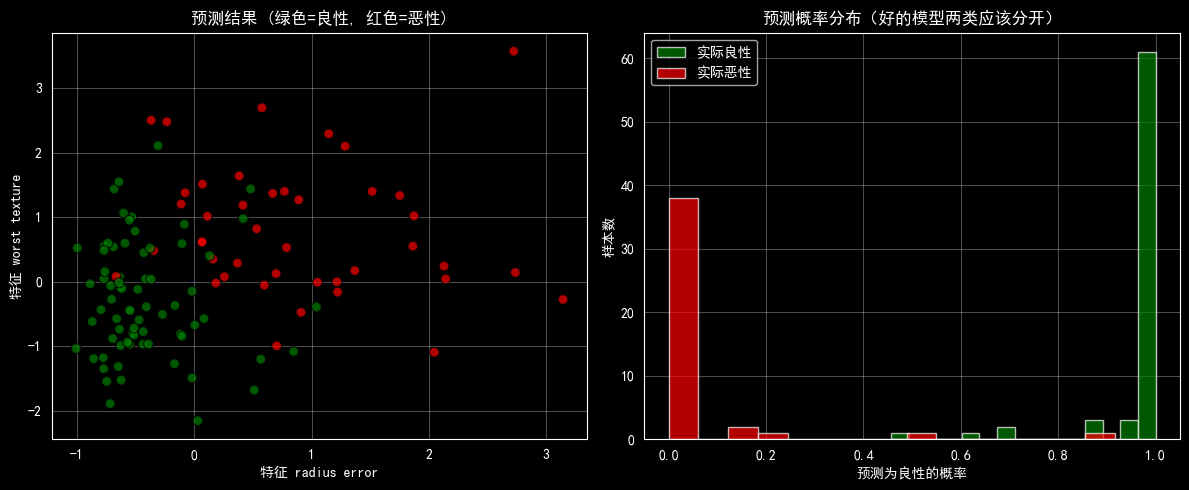

In [9]:
# 用最重要的两个特征画决策边界（简化展示）
# 选择权重绝对值最大的两个特征
weights = model.coef_[0]
top2_idx = np.argsort(np.abs(weights))[-2:]

plt.figure(figsize=(12, 5))

# 子图1：决策边界示意
plt.subplot(1, 2, 1)
xx = X_test[:, top2_idx[0]]
yy = X_test[:, top2_idx[1]]
colors = ['red' if p == 0 else 'green' for p in y_pred]
plt.scatter(xx, yy, c=colors, alpha=0.7, edgecolors='k', s=50)
plt.xlabel(f"特征 {data.feature_names[top2_idx[0]]}")
plt.ylabel(f"特征 {data.feature_names[top2_idx[1]]}")
plt.title("预测结果 (绿色=良性, 红色=恶性)")
plt.grid(True, alpha=0.3)

# 子图2：预测概率分布
plt.subplot(1, 2, 2)
probs = model.predict_proba(X_test)[:, 1]  # 属于良性的概率
plt.hist(probs[y_test == 1], bins=15, alpha=0.7, label='实际良性', color='green')
plt.hist(probs[y_test == 0], bins=15, alpha=0.7, label='实际恶性', color='red')
plt.xlabel("预测为良性的概率")
plt.ylabel("样本数")
plt.title("预测概率分布（好的模型两类应该分开）")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mlp_01_单神经元结果.png", dpi=150)
plt.show()